### import library


In [1]:
!pip install transformers datasets accelerate scikit-learn openpyxl seaborn -q

import json
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    multilabel_confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {device}')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
PyTorch : 2.11.0+cu128


### load json & eksplorasi data

In [2]:
filename = 'absa_labeled_gab.json'

with open(filename, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

ASPEK_COLS = ['produk', 'layanan', 'pengiriman']

print(f'Total review: {len(raw_data)}')
print(f'\nContoh record:')
print(json.dumps(raw_data[0], ensure_ascii=False, indent=2))

print('\n=== Distribusi Aspek ===')
for a in ASPEK_COLS:
    n = sum(1 for d in raw_data if d.get(a) is not None)
    print(f'  {a:12s}: {n} ({n/len(raw_data)*100:.1f}%)')

print('\n=== Distribusi Polarity per Aspek ===')
from collections import Counter
for a in ASPEK_COLS:
    pol = Counter(d[a]['polarity'] for d in raw_data if d.get(a) is not None)
    print(f'  {a:12s}: {dict(pol)}')

Total review: 2937

Contoh record:
{
  "clean_content": "banyak bantu dalam jual beli produk kualitas harga ringan di kantong terima kasih shopee",
  "layanan": {
    "text": "banyak bantu dalam jual beli",
    "polarity": "positif"
  },
  "pengiriman": null,
  "produk": {
    "text": "kualitas harga ringan di kantong",
    "polarity": "positif"
  },
  "other": null
}

=== Distribusi Aspek ===
  produk      : 786 (26.8%)
  layanan     : 1492 (50.8%)
  pengiriman  : 824 (28.1%)

=== Distribusi Polarity per Aspek ===
  produk      : {'positif': 575, 'netral': 7, 'negatif': 204}
  layanan     : {'positif': 536, 'negatif': 932, 'netral': 24}
  pengiriman  : {'positif': 377, 'negatif': 433, 'netral': 14}


### preprocessing data aspek

In [3]:
SENTIMEN_VALID = ['positif', 'negatif']

aspek_records = []
for d in raw_data:
    clean = d['clean_content']
    for aspek in ASPEK_COLS:
        if d.get(aspek) is not None:
            span     = d[aspek].get('text', '').strip()
            polarity = d[aspek].get('polarity', '').lower().strip()
            if polarity not in SENTIMEN_VALID:
                continue
            if not span:
                span = clean  # fallback jika span kosong
            # Multi-label binary: aspek mana span ini berasal = 1, sisanya = 0
            aspek_records.append({
                'clean_content': clean,
                'span':          span,
                'produk':        1 if aspek == 'produk'     else 0,
                'layanan':       1 if aspek == 'layanan'    else 0,
                'pengiriman':    1 if aspek == 'pengiriman' else 0,
            })

df_aspek = pd.DataFrame(aspek_records).reset_index(drop=True)

print(f'Dataset Aspek (Span-based, Multi-label):')
print(f'   Total span: {len(df_aspek)}')
print(f'\nDistribusi label per aspek:')
for a in ASPEK_COLS:
    print(f'   {a:12s}: {df_aspek[a].sum()} ({df_aspek[a].mean()*100:.1f}%)')
print(f'\nContoh span & label:')
for _, row in df_aspek.head(4).iterrows():
    label = [a for a in ASPEK_COLS if row[a]==1]
    print(f'   "{row.span}" → {label}')

Dataset Aspek (Span-based, Multi-label):
   Total span: 3057

Distribusi label per aspek:
   produk      : 779 (25.5%)
   layanan     : 1468 (48.0%)
   pengiriman  : 810 (26.5%)

Contoh span & label:
   "kualitas harga ringan di kantong" → ['produk']
   "banyak bantu dalam jual beli" → ['layanan']
   "buka paket paket yang sudah datang" → ['pengiriman']
   "segala sesuatu kebutuhan ada" → ['produk']


### preprocessing dataset sentimen

In [4]:
SENTIMEN_LABEL    = {'positif': 0, 'negatif': 1}
SENTIMEN_ID2LABEL = {0: 'positif', 1: 'negatif'}

sent_records = []
for d in raw_data:
    clean = d['clean_content']
    for aspek in ASPEK_COLS:
        if d.get(aspek) is not None:
            span     = d[aspek].get('text', '').strip()
            polarity = d[aspek].get('polarity', '').lower().strip()
            if polarity not in SENTIMEN_VALID:
                continue
            if not span:
                span = clean
            sent_records.append({
                'clean_content':  clean,
                'aspek':          aspek,
                'span':           span,
                'polarity':       polarity,
                'sentimen_label': SENTIMEN_LABEL[polarity]
            })

df_sent = pd.DataFrame(sent_records).reset_index(drop=True)

print(f'Dataset Sentimen (Span-based):')
print(f'   Total pasangan (span, aspek): {len(df_sent)}')
print(f'\nDistribusi polarity:')
print(df_sent['polarity'].value_counts().to_string())
print(f'\nDistribusi polarity per aspek:')
print(df_sent.groupby(['aspek','polarity']).size().to_string())
print(f'\nContoh span per aspek:')
for _, row in df_sent.head(4).iterrows():
    print(f'   [{row.aspek}] "{row.span}" → {row.polarity}')

Dataset Sentimen (Span-based):
   Total pasangan (span, aspek): 3057

Distribusi polarity:
polarity
negatif    1569
positif    1488

Distribusi polarity per aspek:
aspek       polarity
layanan     negatif     932
            positif     536
pengiriman  negatif     433
            positif     377
produk      negatif     204
            positif     575

Contoh span per aspek:
   [produk] "kualitas harga ringan di kantong" → positif
   [layanan] "banyak bantu dalam jual beli" → positif
   [pengiriman] "buka paket paket yang sudah datang" → positif
   [produk] "segala sesuatu kebutuhan ada" → positif


### split data aspek dan sentimen

In [5]:
# Split Aspek
stratify_aspek = df_aspek[ASPEK_COLS].astype(str).agg(''.join, axis=1)
train_aspek, temp_aspek = train_test_split(
    df_aspek, test_size=0.2, random_state=42, stratify=stratify_aspek
)
val_aspek, test_aspek = train_test_split(
    temp_aspek, test_size=0.5, random_state=42,
    stratify=temp_aspek[ASPEK_COLS].astype(str).agg(''.join, axis=1)
)
train_aspek = train_aspek.reset_index(drop=True)
val_aspek   = val_aspek.reset_index(drop=True)
test_aspek  = test_aspek.reset_index(drop=True)

# Split Sentimen
stratify_sent = df_sent['aspek'] + '_' + df_sent['polarity']
train_sent, temp_sent = train_test_split(
    df_sent, test_size=0.2, random_state=42, stratify=stratify_sent
)
val_sent, test_sent = train_test_split(
    temp_sent, test_size=0.5, random_state=42,
    stratify=temp_sent['aspek'] + '_' + temp_sent['polarity']
)
train_sent = train_sent.reset_index(drop=True)
val_sent   = val_sent.reset_index(drop=True)
test_sent  = test_sent.reset_index(drop=True)

print('Split selesai!')
print(f'[ASPEK]    Train={len(train_aspek)} | Val={len(val_aspek)} | Test={len(test_aspek)}')
print(f'[SENTIMEN] Train={len(train_sent)} | Val={len(val_sent)} | Test={len(test_sent)}')

Split selesai!
[ASPEK]    Train=2445 | Val=306 | Test=306
[SENTIMEN] Train=2445 | Val=306 | Test=306


###  dataset class & trainer

In [6]:
MODEL_NAME = 'indobenchmark/indobert-base-p1'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

# Dataset Aspek - multi-label
class AspekDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

# Dataset Sentimen - single-label, label = long
class SentimenDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Trainer Aspek — BCEWithLogitsLoss untuk multi-label
class MultilabelTrainer(Trainer):
    def __init__(self, pos_weight=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

# Trainer Sentimen — CrossEntropyLoss + class weight
class WeightedSentimenTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.CrossEntropyLoss(weight=self.class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

print('Dataset class & Trainer siap!')

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Dataset class & Trainer siap!


### Training model asek

In [7]:
# Hitung pos_weight untuk handle imbalance
pos_counts = train_aspek[ASPEK_COLS].sum().values
neg_counts = len(train_aspek) - pos_counts
pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float).to(device)
print('Pos weight per aspek:')
for a, pw in zip(ASPEK_COLS, pos_weight.cpu().numpy()):
    print(f'   {a:12s}: {pw:.3f}')

# Build dataset — input = SPAN (bukan clean_content)
train_labels_aspek = train_aspek[ASPEK_COLS].values.tolist()
val_labels_aspek   = val_aspek[ASPEK_COLS].values.tolist()
test_labels_aspek  = test_aspek[ASPEK_COLS].values.tolist()

ds_train_aspek = AspekDataset(train_aspek['span'].tolist(), train_labels_aspek, tokenizer)
ds_val_aspek   = AspekDataset(val_aspek['span'].tolist(),   val_labels_aspek,   tokenizer)
ds_test_aspek  = AspekDataset(test_aspek['span'].tolist(),  test_labels_aspek,  tokenizer)

model_aspek = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(ASPEK_COLS),
    problem_type='multi_label_classification',
    id2label={i: a for i, a in enumerate(ASPEK_COLS)},
    label2id={a: i for i, a in enumerate(ASPEK_COLS)}
)

# ===============================
# FREEZE LAYER BERT
# ===============================
for param in model_aspek.bert.embeddings.parameters():
    param.requires_grad = False

for layer in model_aspek.bert.encoder.layer[:8]:
    for param in layer.parameters():
        param.requires_grad = False


args_aspek = TrainingArguments(
    output_dir='./model_aspek_span',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=1e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

trainer_aspek = MultilabelTrainer(
    pos_weight=pos_weight,
    model=model_aspek,
    args=args_aspek,
    train_dataset=ds_train_aspek,
    eval_dataset=ds_val_aspek,
)

print(f'\nTraining Model Aspek — Span-based Multi-label...')
print(f'Input: span teks per aspek (field "text" dari JSON)')
print(f'Train={len(ds_train_aspek)} | Val={len(ds_val_aspek)} | Test={len(ds_test_aspek)}')
trainer_aspek.train()
print('Training Model Aspek selesai!')

Pos weight per aspek:
   produk      : 2.925
   layanan     : 1.083
   pengiriman  : 2.773


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Model Aspek selesai!


### evaluasi model aspek

EVALUASI MODEL ASPEK — Span-based Multi-label
thr=0.3: P=0.806 R=0.922 F1-micro=0.860 F1-macro=0.852
thr=0.4: P=0.821 R=0.912 F1-micro=0.864 F1-macro=0.856
thr=0.5: P=0.838 R=0.899 F1-micro=0.868 F1-macro=0.861
thr=0.6: P=0.858 R=0.892 F1-micro=0.875 F1-macro=0.870
thr=0.7: P=0.877 R=0.886 F1-micro=0.881 F1-macro=0.876

Best threshold: 0.7

Classification Report (threshold=0.7):
              precision    recall  f1-score   support

      produk       0.87      0.86      0.86        78
     layanan       0.92      0.88      0.90       147
  pengiriman       0.81      0.91      0.86        81

   micro avg       0.88      0.89      0.88       306
   macro avg       0.87      0.89      0.88       306
weighted avg       0.88      0.89      0.88       306
 samples avg       0.88      0.89      0.88       306

Subset Accuracy (Exact Match): 0.8758


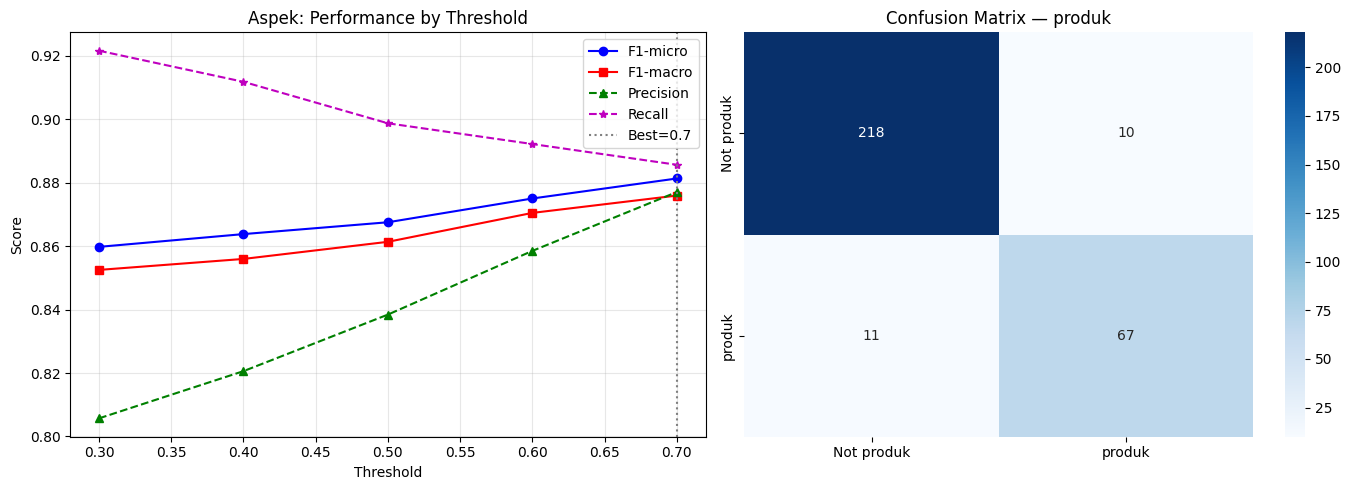

In [8]:
preds_out    = trainer_aspek.predict(ds_test_aspek)
logits       = preds_out.predictions
probs        = torch.sigmoid(torch.tensor(logits)).numpy()
y_true_aspek = np.array(test_labels_aspek)

print('=' * 60)
print('EVALUASI MODEL ASPEK — Span-based Multi-label')
print('=' * 60)

thresholds  = [0.3, 0.4, 0.5, 0.6, 0.7]
thr_results = []
for thr in thresholds:
    y_pred    = (probs >= thr).astype(int)
    zero_mask = y_pred.sum(axis=1) == 0
    y_pred[zero_mask, np.argmax(probs[zero_mask], axis=1)] = 1
    f1_mi = f1_score(y_true_aspek, y_pred, average='micro', zero_division=0)
    f1_ma = f1_score(y_true_aspek, y_pred, average='macro', zero_division=0)
    pr    = precision_score(y_true_aspek, y_pred, average='micro', zero_division=0)
    rc    = recall_score(y_true_aspek, y_pred, average='micro', zero_division=0)
    thr_results.append({'Threshold': thr, 'Precision': pr, 'Recall': rc, 'F1-micro': f1_mi, 'F1-macro': f1_ma})
    print(f'thr={thr}: P={pr:.3f} R={rc:.3f} F1-micro={f1_mi:.3f} F1-macro={f1_ma:.3f}')

thr_df         = pd.DataFrame(thr_results)
best_thr       = thr_df.loc[thr_df['F1-micro'].idxmax(), 'Threshold']
BEST_THRESHOLD = best_thr
print(f'\nBest threshold: {best_thr}')

y_pred_best = (probs >= best_thr).astype(int)
zero_mask   = y_pred_best.sum(axis=1) == 0
y_pred_best[zero_mask, np.argmax(probs[zero_mask], axis=1)] = 1

print(f'\nClassification Report (threshold={best_thr}):')
print(classification_report(y_true_aspek, y_pred_best, target_names=ASPEK_COLS, zero_division=0))


from sklearn.metrics import accuracy_score
subset_acc = accuracy_score(y_true_aspek, y_pred_best)
print(f'Subset Accuracy (Exact Match): {subset_acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thr_df['Threshold'], thr_df['F1-micro'],  'bo-', label='F1-micro')
axes[0].plot(thr_df['Threshold'], thr_df['F1-macro'],  'rs-', label='F1-macro')
axes[0].plot(thr_df['Threshold'], thr_df['Precision'], 'g^--', label='Precision')
axes[0].plot(thr_df['Threshold'], thr_df['Recall'],    'm*--', label='Recall')
axes[0].axvline(x=best_thr, color='gray', linestyle=':', label=f'Best={best_thr}')
axes[0].set_title('Aspek: Performance by Threshold')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

mcm = multilabel_confusion_matrix(y_true_aspek, y_pred_best)
sns.heatmap(mcm[0], annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not '+ASPEK_COLS[0], ASPEK_COLS[0]],
            yticklabels=['Not '+ASPEK_COLS[0], ASPEK_COLS[0]])
axes[1].set_title(f'Confusion Matrix — {ASPEK_COLS[0]}')
plt.tight_layout()
plt.savefig('eval_aspek_span.png', dpi=150, bbox_inches='tight')
plt.show()
thr_df.to_excel('threshold_aspek_span.xlsx', index=False)

### training model sentimen

In [9]:
NUM_SENTIMEN = 2

train_sent = train_sent[train_sent['polarity'].isin(['positif','negatif'])].copy().reset_index(drop=True)
val_sent   = val_sent[val_sent['polarity'].isin(['positif','negatif'])].copy().reset_index(drop=True)
test_sent  = test_sent[test_sent['polarity'].isin(['positif','negatif'])].copy().reset_index(drop=True)

train_sent['sentimen_label'] = train_sent['polarity'].map(SENTIMEN_LABEL)
val_sent['sentimen_label']   = val_sent['polarity'].map(SENTIMEN_LABEL)
test_sent['sentimen_label']  = test_sent['polarity'].map(SENTIMEN_LABEL)

cw        = compute_class_weight('balanced', classes=np.arange(NUM_SENTIMEN), y=train_sent['sentimen_label'].values)
cw_tensor = torch.tensor(cw, dtype=torch.float).to(device)
print('Class weight sentimen:')
for label, w in zip(SENTIMEN_LABEL.keys(), cw):
    print(f'   {label:10s}: {w:.3f}')

# SPAN sebagai input
ds_train_sent = SentimenDataset(train_sent['span'].tolist(), train_sent['sentimen_label'].tolist(), tokenizer)
ds_val_sent   = SentimenDataset(val_sent['span'].tolist(),   val_sent['sentimen_label'].tolist(),   tokenizer)
ds_test_sent  = SentimenDataset(test_sent['span'].tolist(),  test_sent['sentimen_label'].tolist(),  tokenizer)

model_sentimen = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_SENTIMEN,
    id2label=SENTIMEN_ID2LABEL, label2id=SENTIMEN_LABEL
)

# ===============================
# FREEZE LAYER BERT
# ===============================
for param in model_sentimen.bert.embeddings.parameters():
    param.requires_grad = False

for layer in model_sentimen.bert.encoder.layer[:8]:
    for param in layer.parameters():
        param.requires_grad = False

args_sent = TrainingArguments(
    output_dir='./model_sentimen_span',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=1e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

trainer_sent = WeightedSentimenTrainer(
    class_weights=cw_tensor,
    model=model_sentimen,
    args=args_sent,
    train_dataset=ds_train_sent,
    eval_dataset=ds_val_sent,
)

print(f'\nTraining Model Sentimen — Span-based...')
print(f'Input: span teks per aspek (field "text" dari JSON)')
print(f'Train={len(ds_train_sent)} | Val={len(ds_val_sent)} | Test={len(ds_test_sent)}')
trainer_sent.train()
print('Training selesai!')

Class weight sentimen:
   positif   : 1.026
   negatif   : 0.975


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Training Model Sentimen — Span-based...
Input: span teks per aspek (field "text" dari JSON)
Train=2445 | Val=306 | Test=306


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training selesai!


### evaluasi model sentimen

EVALUASI MODEL SENTIMEN — Span-based
              precision    recall  f1-score   support

     positif       0.97      0.97      0.97       149
     negatif       0.97      0.97      0.97       157

    accuracy                           0.97       306
   macro avg       0.97      0.97      0.97       306
weighted avg       0.97      0.97      0.97       306

Evaluasi per aspek:
  produk      : F1=0.961 | Acc=0.962 | n=78
  layanan     : F1=0.973 | Acc=0.973 | n=147
  pengiriman  : F1=0.975 | Acc=0.975 | n=81

Ringkasan — F1 weighted: 0.9706 | Accuracy: 0.9706


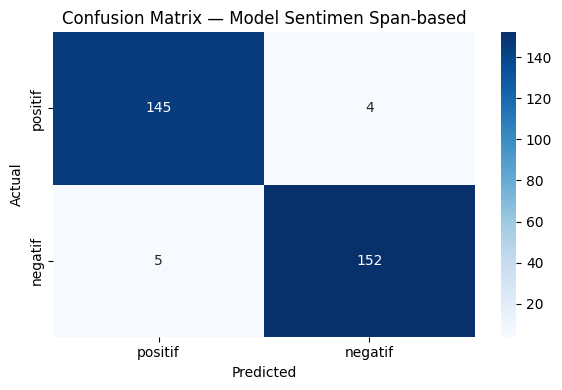

In [10]:
preds_sent  = trainer_sent.predict(ds_test_sent)
y_pred_sent = np.argmax(preds_sent.predictions, axis=1)
y_true_sent = test_sent['sentimen_label'].values

print('=' * 55)
print('EVALUASI MODEL SENTIMEN — Span-based')
print('=' * 55)
print(classification_report(
    y_true_sent, y_pred_sent,
    target_names=list(SENTIMEN_LABEL.keys()),
    zero_division=0
))

print('Evaluasi per aspek:')
for aspek in ASPEK_COLS:
    mask = (test_sent['aspek'] == aspek).values
    if mask.sum() == 0: continue
    f1  = f1_score(y_true_sent[mask], y_pred_sent[mask], average='weighted', zero_division=0)
    acc = (y_true_sent[mask] == y_pred_sent[mask]).mean()
    print(f'  {aspek:12s}: F1={f1:.3f} | Acc={acc:.3f} | n={mask.sum()}')

f1_sent  = f1_score(y_true_sent, y_pred_sent, average='weighted', zero_division=0)
acc_sent = (y_true_sent == y_pred_sent).mean()
print(f'\nRingkasan — F1 weighted: {f1_sent:.4f} | Accuracy: {acc_sent:.4f}')

cm_sent = confusion_matrix(y_true_sent, y_pred_sent)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(SENTIMEN_LABEL.keys()),
            yticklabels=list(SENTIMEN_LABEL.keys()))
plt.title('Confusion Matrix — Model Sentimen Span-based')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('eval_sentimen_span.png', dpi=150, bbox_inches='tight')
plt.show()

### pipeline coba coba

In [11]:
def absa_pipeline_span(reviews, model_aspek, model_sentimen, tokenizer,
                       aspek_threshold=0.3, device='cpu'):
    model_aspek.eval().to(device)
    model_sentimen.eval().to(device)
    results = []
    for review in reviews:
        # Step 1: Prediksi Aspek dari full review
        # (saat inferensi tidak ada span, pakai full review)
        enc = tokenizer(str(review), max_length=128, padding='max_length',
                        truncation=True, return_tensors='pt').to(device)
        with torch.no_grad():
            probs_aspek = torch.sigmoid(model_aspek(**enc).logits).cpu().numpy()[0]

        aspek_probs = {a: round(float(p), 3) for a, p in zip(ASPEK_COLS, probs_aspek)}
        aspek_aktif = [a for a, p in zip(ASPEK_COLS, probs_aspek) if p >= aspek_threshold]
        if not aspek_aktif:
            aspek_aktif = [ASPEK_COLS[np.argmax(probs_aspek)]]

        # Step 2: Prediksi Sentimen per aspek
        sentimen_per_aspek = {}
        for aspek in aspek_aktif:
            enc_s = tokenizer(str(review), max_length=128, padding='max_length',
                              truncation=True, return_tensors='pt').to(device)
            with torch.no_grad():
                probs_s = torch.softmax(model_sentimen(**enc_s).logits, dim=-1).cpu().numpy()[0]
            pred_label = SENTIMEN_ID2LABEL[int(np.argmax(probs_s))]
            sentimen_per_aspek[aspek] = {'label': pred_label, 'confidence': round(float(max(probs_s)), 3)}

        results.append({
            'review':      review,
            'aspek_probs': aspek_probs,
            'aspek_aktif': aspek_aktif,
            'sentimen':    sentimen_per_aspek
        })
    return results

demo = [
    "barang bagus kualitas oke tapi pengiriman lambat banget",
    "penjual ramah respon cepat barang sesuai deskripsi",
    "paket rusak waktu sampai penjual tidak mau tanggung jawab",
    "sangat puas semua oke dari produk sampai pengiriman",
]

print('Demo Pipeline ABSA — Span-based Multi-label:')
print('=' * 65)
res = absa_pipeline_span(demo, model_aspek, model_sentimen, tokenizer, device=device)
for r in res:
    print(f'\nReview: "{r["review"]}"')
    print(f'  Aspek probs : {r["aspek_probs"]}')
    print(f'  Aspek aktif : {r["aspek_aktif"]}')
    for aspek, sent in r['sentimen'].items():
        print(f'  -> {aspek:12s}: {sent["label"]} (conf={sent["confidence"]})')

Demo Pipeline ABSA — Span-based Multi-label:

Review: "barang bagus kualitas oke tapi pengiriman lambat banget"
  Aspek probs : {'produk': 0.874, 'layanan': 0.003, 'pengiriman': 0.832}
  Aspek aktif : ['produk', 'pengiriman']
  -> produk      : negatif (conf=0.964)
  -> pengiriman  : negatif (conf=0.964)

Review: "penjual ramah respon cepat barang sesuai deskripsi"
  Aspek probs : {'produk': 0.606, 'layanan': 0.411, 'pengiriman': 0.007}
  Aspek aktif : ['produk', 'layanan']
  -> produk      : positif (conf=0.997)
  -> layanan     : positif (conf=0.997)

Review: "paket rusak waktu sampai penjual tidak mau tanggung jawab"
  Aspek probs : {'produk': 0.035, 'layanan': 0.066, 'pengiriman': 0.903}
  Aspek aktif : ['pengiriman']
  -> pengiriman  : negatif (conf=0.999)

Review: "sangat puas semua oke dari produk sampai pengiriman"
  Aspek probs : {'produk': 0.963, 'layanan': 0.011, 'pengiriman': 0.152}
  Aspek aktif : ['produk']
  -> produk      : positif (conf=0.999)
